In [1]:
import pandas as pd
import json
import subprocess
import os
import matplotlib.pyplot as plt
import seaborn as sns

# GSE prediction on selected parent-children models

In [2]:
model_ids = ['MONDO_0004992', 'MONDO_0000621', 'MONDO_0021138', 'MONDO_0020076', 'MONDO_0004643', 'MONDO_0011996']

for id in model_ids:
    subprocess.run([
        "python", "../src/predict.py",
        "-input", "../demo/metadata_mouse_title_processed.tsv",
        "-id", "../demo/metadata_mouse_ID.tsv",
        "-input_embed", "../demo/metadata_mouse_title_embedding.npz",
        "-train_embed", "../data/disease_desc_embedding.npz",
        "-model", f"../bins/{id}__model.pkl",
        "-out", "../results/mouse_0004992_to_0011996/"
    ])

/home/rfu_smith_edu/.local/lib/python3.13/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.2.1 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


loading data
took 0.89 s to load data
predicting labels
took 9.99 s to predict
retrieving predictive words
took 0.45 s to retrieve predictive words
saving output
took 0.19 min to load, predict, retrieve predictive words and save MONDO_0004992 for 4066 instances


/home/rfu_smith_edu/.local/lib/python3.13/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.2.1 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


loading data
took 0.86 s to load data
predicting labels
took 10.05 s to predict
retrieving predictive words
took 0.35 s to retrieve predictive words
saving output
took 0.19 min to load, predict, retrieve predictive words and save MONDO_0000621 for 4066 instances


/home/rfu_smith_edu/.local/lib/python3.13/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.2.1 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


...

loading data
took 0.86 s to load data
predicting labels
took 9.94 s to predict
retrieving predictive words
took 0.32 s to retrieve predictive words
saving output
took 0.19 min to load, predict, retrieve predictive words and save MONDO_0020076 for 4066 instances


/home/rfu_smith_edu/.local/lib/python3.13/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.2.1 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


loading data
took 0.88 s to load data
predicting labels
took 9.89 s to predict
retrieving predictive words
took 0.32 s to retrieve predictive words
saving output
took 0.19 min to load, predict, retrieve predictive words and save MONDO_0004643 for 4066 instances


/home/rfu_smith_edu/.local/lib/python3.13/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.2.1 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


loading data
took 0.89 s to load data
predicting labels
took 9.89 s to predict
retrieving predictive words
took 0.30 s to retrieve predictive words
saving output
took 0.19 min to load, predict, retrieve predictive words and save MONDO_0011996 for 4066 instances


In [9]:
files = [f for f in os.listdir("../results/mouse_0004992_to_0011996/") if f.endswith(".csv")]
dfs = []
for f in files:
    df = pd.read_csv(os.path.join("../results/mouse_0004992_to_0011996/", f))
    df['source'] = f.replace("__preds.csv", "")
    dfs.append(df)
all_preds = pd.concat(dfs, ignore_index=True)
all_preds.to_csv("../results/mouse_0004992_to_0011996/all_cancer_predictions.csv", index=False)
print("Saved all_cancer_predictions.csv")

Saved all_cancer_predictions.csv


In [10]:
all_preds = all_preds[all_preds['log2(prob/prior)'] > 0]
all_preds

,ID,prob,log2(prob/prior),related_words,source
0,GSE53599,0.901800,3.645097,"acute,aml,cells,knockdown,leukemia,myeloid",MONDO_0000621
1,GSE87870,0.795060,3.463353,"acute,leukemia,myeloid,rna",MONDO_0000621
2,GSE90059,0.751107,3.381309,"aml,cells,knockdown,rnaseq",MONDO_0000621
3,GSE48048,0.720668,3.321625,"cells,leukemia,myeloid",MONDO_0000621
4,GSE88905,0.711232,3.302610,"aml,bone,cells,marrow",MONDO_0000621
...,...,...,...,...,...
20553,GSE55291,0.049512,0.012459,"noncoding,rna",MONDO_0021138
20554,GSE60005,0.049486,0.011704,"cells,chromatin,hsc",MONDO_0021138
20555,GSE63497,0.049347,0.007653,"enhancer,rnaseq",MONDO_0021138
20556,GSE74868,0.049235,0.004361,"cell,chromatin,ii,rnaseq",MONDO_0021138


# Prediction analysis

In [11]:
dist = all_preds.groupby('ID').size().reset_index(name='count').sort_values('count', ascending=False).groupby('count').size().reset_index(name='num')
dist

,count,num
0,1,1170
1,2,113
2,3,24
3,4,47
4,5,154
5,6,12


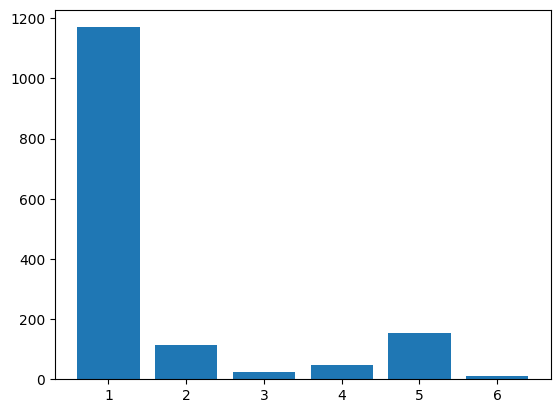

In [12]:
plt.bar(dist['count'], dist['num'])
plt.show()

In [13]:
GSE_ids = all_preds.groupby('ID').size().reset_index(name='count')[all_preds.groupby('ID').size().reset_index(name='count')['count'] == 6]['ID'].tolist()
GSE_ids

['GSE48048',
 'GSE53599',
 'GSE65383',
 'GSE66068',
 'GSE72628',
 'GSE74650',
 'GSE78224',
 'GSE79068',
 'GSE80745',
 'GSE81329',
 'GSE87870',
 'GSE90059']

In [14]:
subset_preds = all_preds[all_preds['ID'].isin(GSE_ids)]
subset_preds

,ID,prob,log2(prob/prior),related_words,source
0,GSE53599,0.901800,3.645097,"acute,aml,cells,knockdown,leukemia,myeloid",MONDO_0000621
1,GSE87870,0.795060,3.463353,"acute,leukemia,myeloid,rna",MONDO_0000621
2,GSE90059,0.751107,3.381309,"aml,cells,knockdown,rnaseq",MONDO_0000621
3,GSE48048,0.720668,3.321625,"cells,leukemia,myeloid",MONDO_0000621
5,GSE66068,0.673152,3.223222,"acute,hematopoietic,leukemia,myeloid,rnaseq,tr...",MONDO_0000621
...,...,...,...,...,...
20342,GSE74650,0.499889,3.348213,"acute,cells,leukemia,myeloid,rnaseq",MONDO_0021138
20344,GSE78224,0.482666,3.297631,"acute,cells,ii,leukemia,myeloid,rnaseq",MONDO_0021138
20345,GSE81329,0.471071,3.262551,"aml,aml1eto,partner,rnaseq",MONDO_0021138
20358,GSE72628,0.317200,2.692000,"acute,myeloid,rnaseq",MONDO_0021138


In [32]:
subset_preds['source'].astype('category')
order = ['MONDO_0004992', 'MONDO_0000621', 'MONDO_0021138', 'MONDO_0020076', 'MONDO_0004643', 'MONDO_0011996']
subset_preds['source'] = subset_preds['source'].cat.reorder_categories(order, ordered=True)

/tmp/ipykernel_1787999/3560231680.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_preds['source'] = subset_preds['source'].cat.reorder_categories(order, ordered=True)


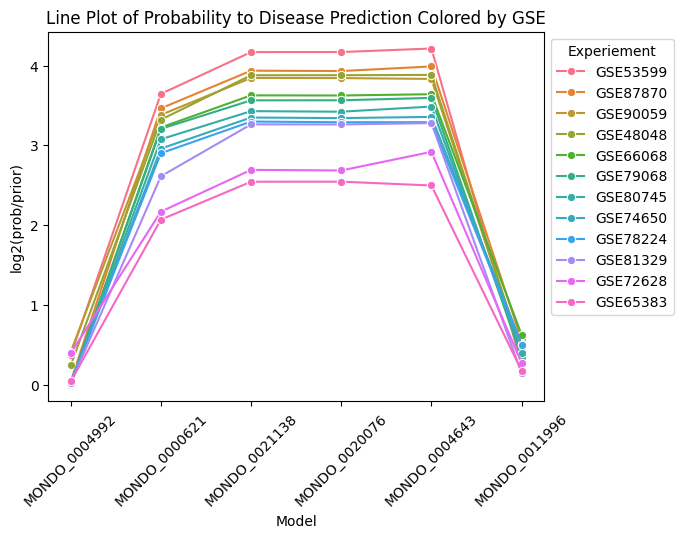

In [42]:
ax = sns.lineplot(data=subset_preds, x='source', y='log2(prob/prior)', hue='ID', marker='o')
plt.title('Line Plot of Probability to Disease Prediction Colored by GSE')
plt.xlabel('Model')
plt.xticks(rotation=45)
plt.ylabel('log2(prob/prior)')
plt.legend(title='Experiement')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.show()